# SHARA

## Import Library

In [1]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from keras.preprocessing.image import ImageDataGenerator

## Load Data

In [2]:
base_path = "./data"

# Train Dataset
train_dry = os.path.join(base_path + "/train/dry")
train_normal = os.path.join(base_path + "/train/normal")
train_oily = os.path.join(base_path + "/train/oily")

# Validation Dataset
valid_dry = os.path.join(base_path + "/valid/dry")
valid_normal = os.path.join(base_path + "/valid/normal")
valid_oily = os.path.join(base_path + "/valid/oily")

# Test Dataset
test_dry = os.path.join(base_path + "/test/dry")
test_normal = os.path.join(base_path + "/test/normal")
test_oily = os.path.join(base_path + "/test/oily")

#### Show Sample Images 

 Training Dry Skin:
Shape: (640, 640, 3)


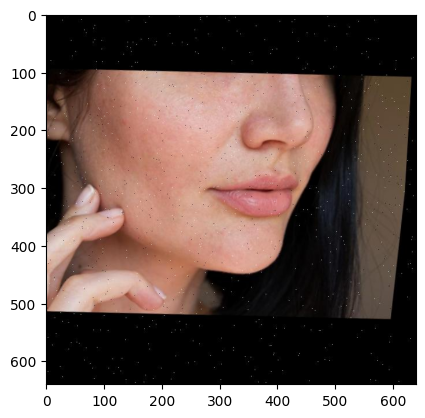

 Training Normal Skin:
Shape: (640, 640, 3)


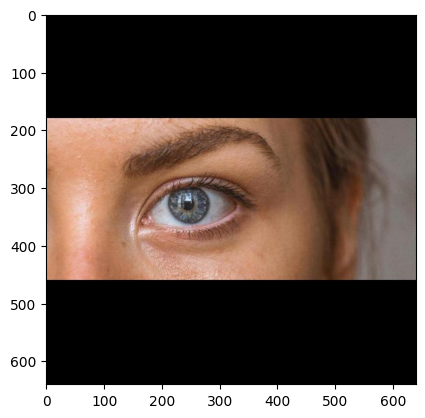

 Training Oily Skin:
Shape: (640, 640, 3)


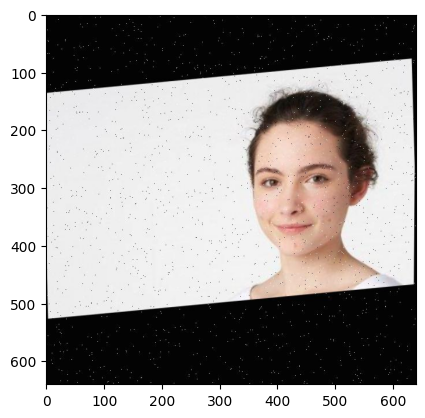

 Validation Dry Skin:
Shape: (640, 640, 3)


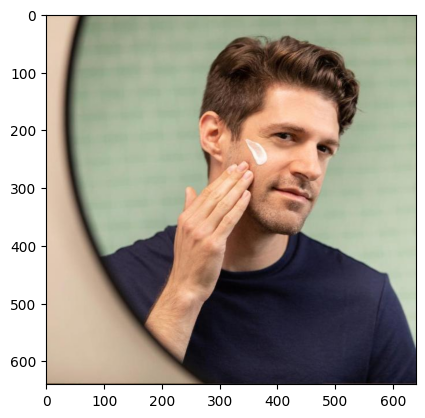

 Validation Normal Skin:
Shape: (640, 640, 3)


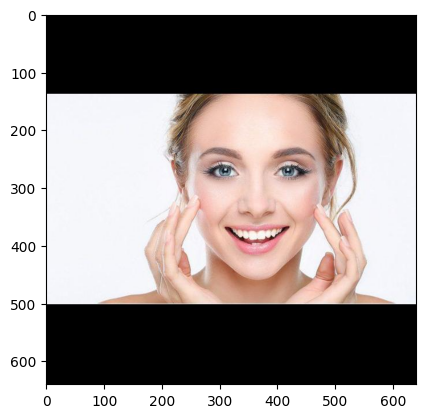

 Validation Oily Skin:
Shape: (640, 640, 3)


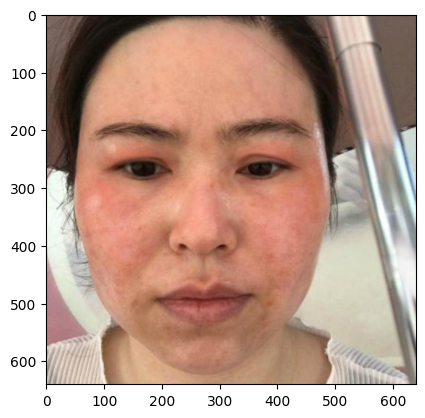

 Test Dry Skin:
Shape: (640, 640, 3)


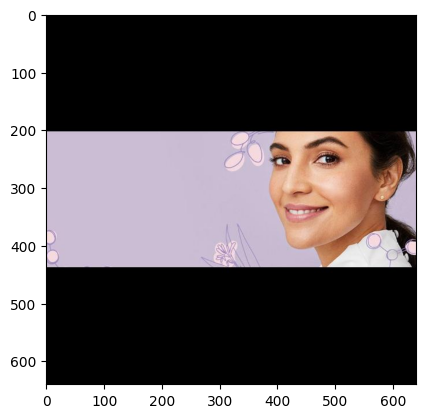

 Test Normal Skin:
Shape: (640, 640, 3)


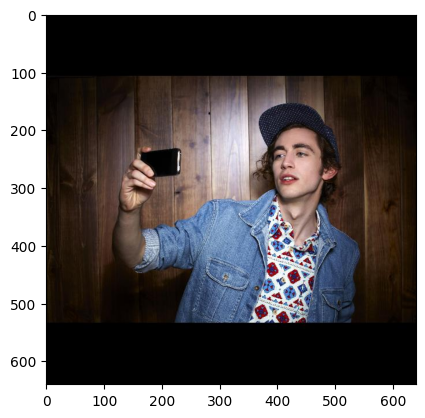

 Test Oily Skin:
Shape: (640, 640, 3)


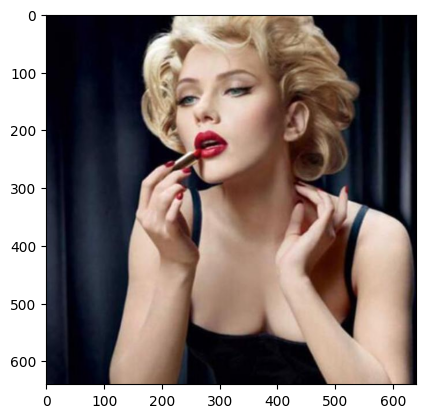

In [3]:
def show_sample_img(folder_path):
    image_files = os.listdir(folder_path)
    image_path = os.path.join(folder_path, image_files[0])
    img = mpimg.imread(image_path)  # Baca gambar
    print(f"Shape: {img.shape}")

    plt.imshow(img)
    plt.show()

# Train
print(" Training Dry Skin:")
show_sample_img(train_dry)
print(" Training Normal Skin:")
show_sample_img(train_normal)
print(" Training Oily Skin:")
show_sample_img(train_oily)

# Valid
print(" Validation Dry Skin:")
show_sample_img(valid_dry)
print(" Validation Normal Skin:")
show_sample_img(valid_normal)
print(" Validation Oily Skin:")
show_sample_img(valid_oily)

# Test
print(" Test Dry Skin:")
show_sample_img(test_dry)
print(" Test Normal Skin:")
show_sample_img(test_normal)
print(" Test Oily Skin:")
show_sample_img(test_oily)


## Modelling 

Convolutional Neural Network Layers


In [4]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), input_shape=(224, 224, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax') # output layer 3 kategori 
])

Compile model

In [5]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

Train the model

In [6]:
training_dir = os.path.join(base_path + "/train")

datagen = ImageDataGenerator(
    rescale = 1 / 255,
    rotation_range = 40,
    zoom_range = .2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

train_generator = datagen.flow_from_directory(
    training_dir,
    batch_size = 32,
    class_mode = 'categorical',
    target_size = (224, 224)
)


Found 2756 images belonging to 3 classes.


In [7]:
valid_dir = os.path.join(base_path + "/valid")

valid_generator = datagen.flow_from_directory(
    valid_dir,
    batch_size=32,
    class_mode='categorical',
    target_size=(224, 224)
)

Found 262 images belonging to 3 classes.


In [8]:
history = model.fit(
    train_generator,
    validation_data = valid_generator,
    epochs = 10
)

Epoch 1/10


87/87 [==============================] - 371s 4s/step - loss: 4.2839 - accuracy: 0.3839 - val_loss: 1.0808 - val_accuracy: 0.4160
Epoch 2/10
87/87 [==============================] - 326s 4s/step - loss: 1.0735 - accuracy: 0.3999 - val_loss: 1.1059 - val_accuracy: 0.3626
Epoch 3/10
87/87 [==============================] - 375s 4s/step - loss: 1.0646 - accuracy: 0.4129 - val_loss: 1.0915 - val_accuracy: 0.4237
Epoch 4/10
87/87 [==============================] - 308s 3s/step - loss: 1.0623 - accuracy: 0.4086 - val_loss: 1.1176 - val_accuracy: 0.3588
Epoch 5/10
87/87 [==============================] - 215s 2s/step - loss: 1.0561 - accuracy: 0.4318 - val_loss: 1.1254 - val_accuracy: 0.3855
Epoch 6/10
87/87 [==============================] - 212s 2s/step - loss: 1.0576 - accuracy: 0.4510 - val_loss: 1.1524 - val_accuracy: 0.3969
Epoch 7/10
87/87 [==============================] - 196s 2s/step - loss: 1.0508 - accuracy: 0.4321 - val_loss: 1.1549 - val_accuracy: 0.4046
Epoch 8/10


#### Model Accuracy 

In [9]:
test_dir = os.path.join(base_path + "/test")

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Evaluate
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.2f}")

Found 134 images belonging to 3 classes.
5/5 [==============================] - 10s 2s/step - loss: 1.2082 - accuracy: 0.3657
Test Accuracy: 0.37


#### Save Model

In [10]:
model.save('skin_type_model.h5')

c:\Users\syahb\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
